Problem Statement:


An e-commerce company, ShopSmart, wants to better understand the behaviour
of visitors browsing its online store. Every day, thousands of users navigate
through product pages, spend varying amounts of time on the website, and
interact differently with content. Currently, the company is unable to accurately
predict which visitors are likely to complete a purchase, resulting in inefficient
marketing strategies and lost revenue opportunities.
To address this challenge, the company has collected data from 12,330 individual
user sessions over a period of one year. Each session represents a unique visitor
to ensure unbiased insights, avoiding the influence of specific users, promotional
campaigns, seasonal trends, or special events. The dataset includes a mix of
numerical and categorical features that capture detailed information about
users' browsing behaviour and interactions with the website.
You are hired as a Machine Learning Engineer to build a predictive model that
can determine whether a visitor is likely to make a purchase based on their
session behaviour. Your task involves performing exploratory data analysis
(EDA), applying appropriate feature preprocessing and transformations, and
developing a Decision Tree based classification model. Since the dataset is
imbalanced, model performance must be evaluated using the F1 score, with a
benchmark value of 0.55 used to assess the effectiveness of the solution.

Note - Make use of pruning to improve the performance of Decision Tree
Classifier.

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("shop_smart_ecommerce.csv")

In [3]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [5]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Month"] = le.fit_transform(df["Month"])
df["VisitorType"] = le.fit_transform(df["VisitorType"])
df["Weekend"] = le.fit_transform(df["Weekend"])
df["Revenue"] = le.fit_transform(df["Revenue"])

In [7]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,1,0


In [8]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=["Revenue"])
y = df["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [10]:
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier

maxDepths = [2,3,4,5,6,7,8,9,10]

for depth in maxDepths:
    model = DecisionTreeClassifier(max_depth = depth)
    model.fit(X_train, y_train)
    y_predict = model.predict(X_test)
    print("f1 core of DT at depth ", depth ," is ", f1_score(y_test, y_predict))

f1 core of DT at depth  2  is  0.5256609642301711
f1 core of DT at depth  3  is  0.6436781609195402
f1 core of DT at depth  4  is  0.6308724832214765
f1 core of DT at depth  5  is  0.5744047619047619
f1 core of DT at depth  6  is  0.6246648793565683
f1 core of DT at depth  7  is  0.6132971506105834
f1 core of DT at depth  8  is  0.6246498599439776
f1 core of DT at depth  9  is  0.6065573770491803
f1 core of DT at depth  10  is  0.6105834464043419


In [11]:
model = DecisionTreeClassifier(max_depth = 3)

model.fit(X_train, y_train)
y_predict = model.predict(X_test)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


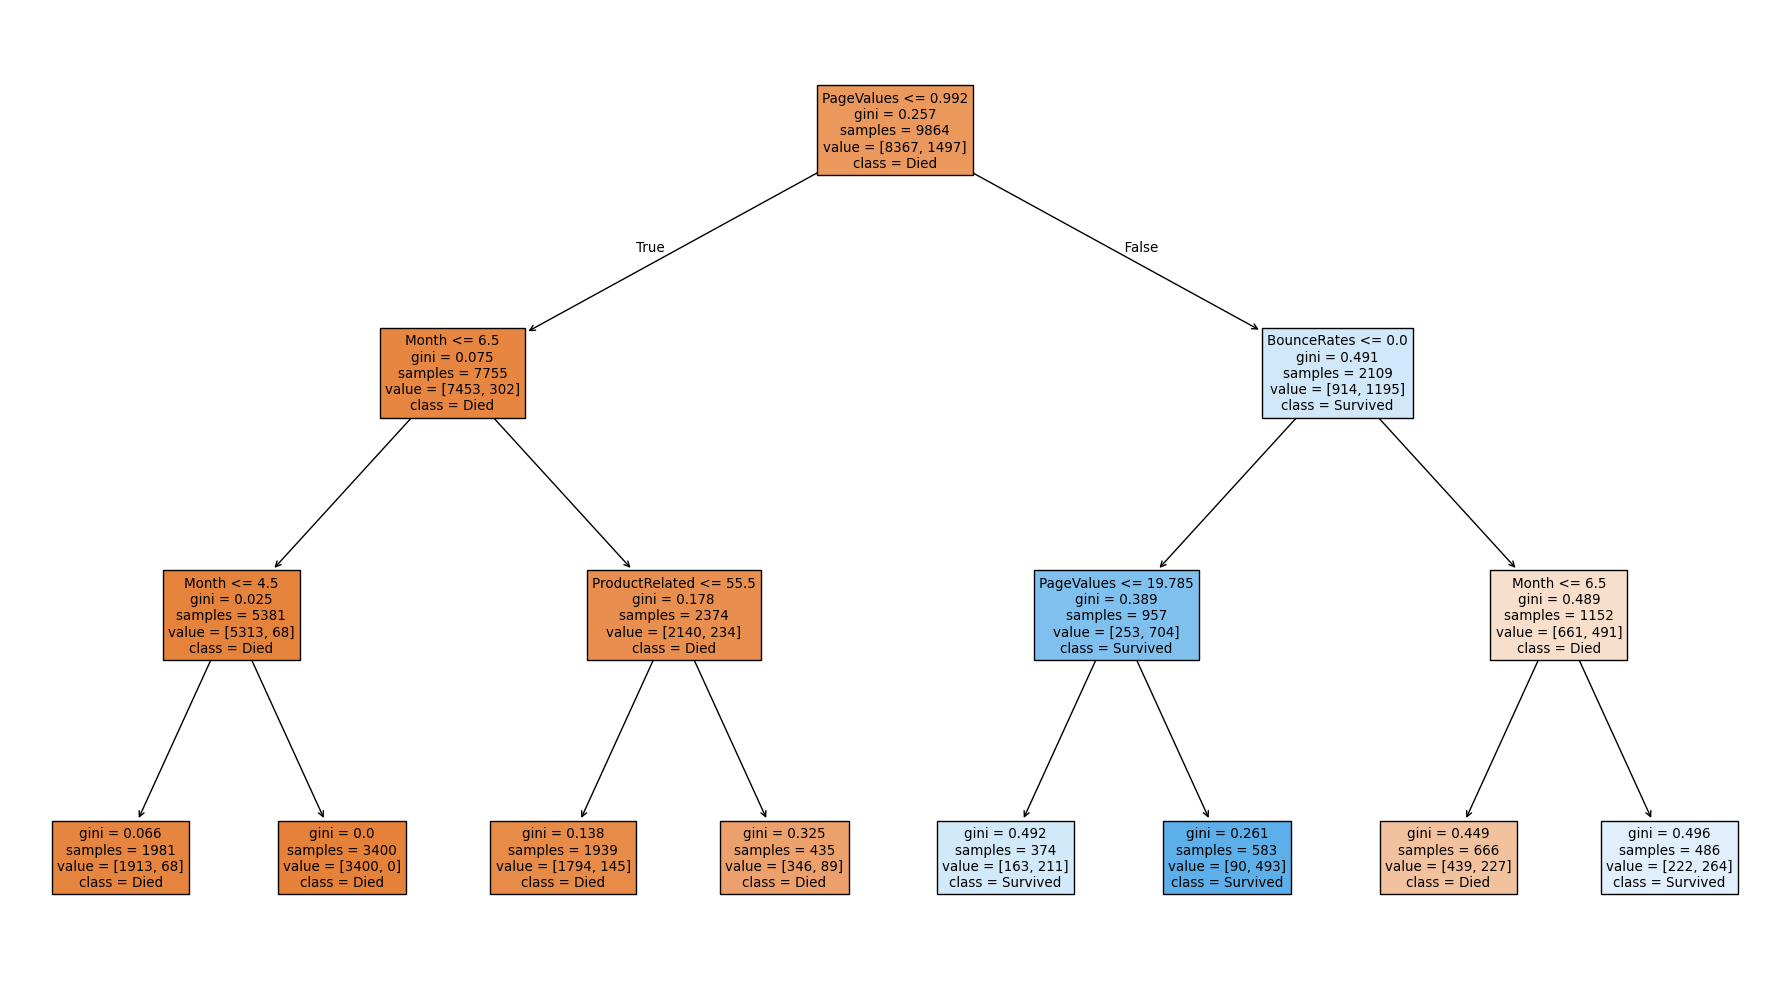

In [12]:
#To plot the tree:

from sklearn.tree import plot_tree
plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import f1_score

y_predict = model.predict(X_test)

print("f1 core of DT without pruning is ", f1_score(y_test, y_predict))

f1 core of DT without pruning is  0.6436781609195402
